# The Fragile Equilibrium: 
## Global Imbalances and International Monetary System

_Question: How do persistent global imbalances between deficit economies and surplus economies shape the functioning and stability of the international monetary system?_

In [42]:
import pandas as pd
import matplotlib.pyplot as plt

### Argument 1: The Systematic “Recycling” Loop

**Claim:** The IMS is sustained by “Global Saving Glut” where surplus nations are forced to recycle their profits into the debt of deficit nations, creating a fragile, debt dependent cycle.

In [43]:
df_stacked = pd.read_csv('./data/WEO_CA.csv')

df_imf = df_stacked.pivot(index = 'TIME_PERIOD', columns='COUNTRY', values='OBS_VALUE')

df_imf = df_imf.reset_index()

df_imf.columns.name = None

df_imf = df_imf.rename(columns={
    'TIME_PERIOD': 'Year',
    'China, People\'s Republic of': 'China',
    'Türkiye, Republic of': 'Turkey',
    'United States': 'USA',
    'Saudi Arabia': 'Saudi_Arabia'
})

df_imf.head()

,Year,China,Germany,Saudi_Arabia,Turkey,USA
0,1997,3.819,-0.344,0.184,-1.007,-1.641
1,1998,3.039,-0.498,-8.947,0.720,-2.373
2,1999,1.918,-1.157,0.254,-0.364,-2.976
3,2000,1.674,-1.524,7.555,-3.626,-3.921
4,2001,1.288,-0.173,5.080,1.852,-3.724


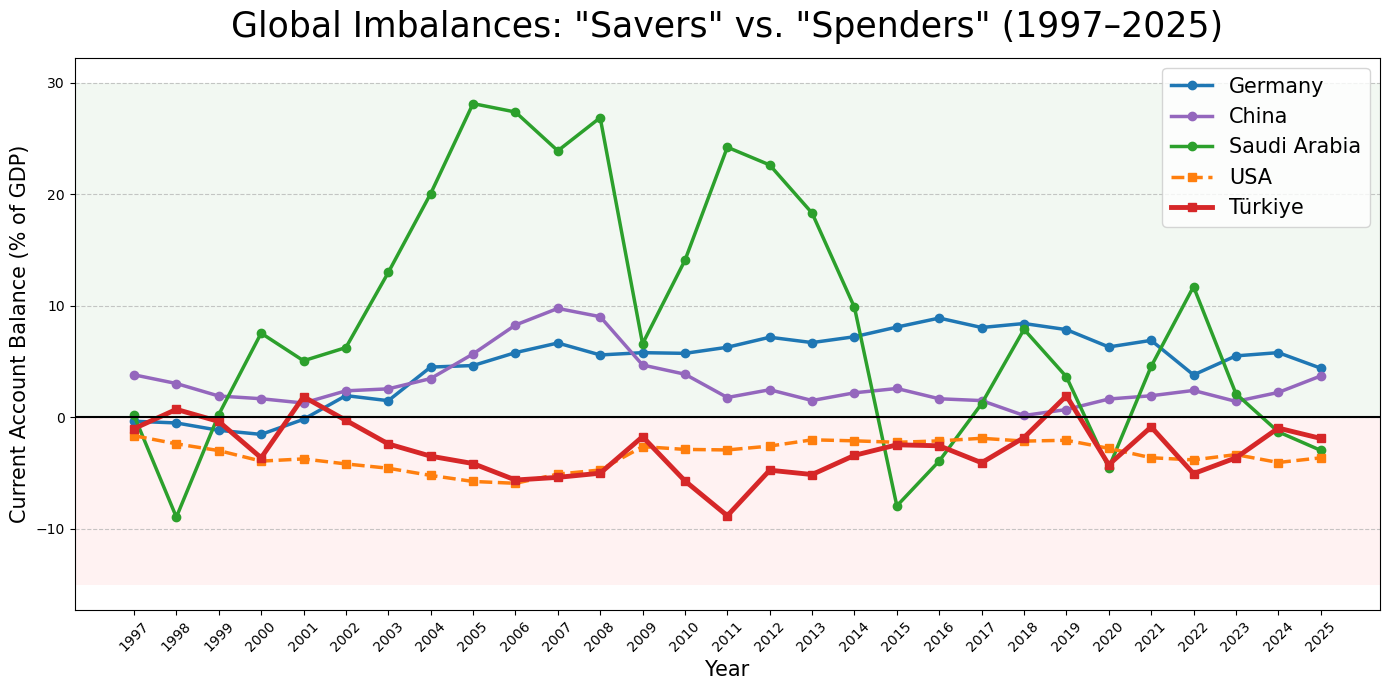

In [44]:
fig, ax = plt.subplots(figsize=(14, 7))

# plot the "Savers" (Surplus Countries)
ax.plot(df_imf['Year'], df_imf['Germany'], color='tab:blue', linewidth=2.5, marker='o', label='Germany')
ax.plot(df_imf['Year'], df_imf['China'], color='tab:purple', linewidth=2.5, marker='o', label='China')
ax.plot(df_imf['Year'], df_imf['Saudi_Arabia'], color='tab:green', linewidth=2.5, marker='o', label='Saudi Arabia')

# plot the "Spenders" (Deficit Countries)
ax.plot(df_imf['Year'], df_imf['USA'], color='tab:orange', linewidth=2.5, marker='s', linestyle='--', label='USA')
ax.plot(df_imf['Year'], df_imf['Turkey'], color='tab:red', linewidth=3.5, marker='s', label='Türkiye')

ax.axhline(0, color='black', linestyle='-', linewidth=1.5)

# shade the Surplus and Deficit zones
ax.axhspan(0, 30, facecolor='green', alpha=0.05) 
ax.axhspan(-15, 0, facecolor='red', alpha=0.05)   

# formatting
ax.set_xlabel('Year', fontsize=15)
ax.set_ylabel('Current Account Balance (% of GDP)', fontsize=15)
ax.set_title('Global Imbalances: "Savers" vs. "Spenders" (1997–2025)', fontsize=25, pad=15)

ax.set_xticks(df_imf['Year'])
ax.set_xticklabels(df_imf['Year'], rotation=45)

ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.legend(loc='upper right', frameon=True, fontsize=15)

fig.tight_layout()
plt.show()

### Argument 2: Energy-Driven Structural Vulnerability 
**Claim:** For energy importing markets like Türkiye, The CA deficit is structural and inelastic. This means the country’s monetary stability is directly tied to global commodity prices.

In [45]:
CA_balance_df = pd.read_excel('./data/turkiye_CA_balance.xlsx', usecols=[0,1,2])[:278]

CA_balance_df['Date'] = pd.to_datetime(CA_balance_df['Date'])
CA_balance_df = CA_balance_df.rename(columns={
    'Date': 'date',
    'TP_HARICCARIACIK_K1': 'total_current_account',
    'TP_HARICCARIACIK_K10': 'core_current_account'
}) 

CA_balance_df

c:\Users\sahin\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,date,total_current_account,core_current_account
0,2003-01-01,-270,752.92
1,2003-02-01,-1415,-436.32
2,2003-03-01,-1397,-140.08
3,2003-04-01,-939,10.54
4,2003-05-01,-706,229.86
...,...,...,...
273,2025-10-01,439,6991.45
274,2025-11-01,-4108,2024.52
275,2025-12-01,-7426,-796.46
276,2026-01-01,-7042,-1476.01


In [46]:
global_oil_price_df = pd.read_excel('./data/global_price_brent_crude.xlsx', sheet_name=1)

global_oil_price_df['observation_date'] = pd.to_datetime(global_oil_price_df['observation_date'])
global_oil_price_df = global_oil_price_df.rename(columns={
    'observation_date': 'date',
    'POILBREUSDM': 'oil_price'
})

global_oil_price_df

,date,oil_price
0,2003-01-01,30.808696
1,2003-02-01,32.662500
2,2003-03-01,30.168095
3,2003-04-01,25.035000
4,2003-05-01,25.714545
...,...,...
273,2025-10-01,63.981304
274,2025-11-01,63.693500
275,2025-12-01,61.810909
276,2026-01-01,64.594091


In [47]:
combined_df = pd.merge(CA_balance_df, global_oil_price_df, on='date', how='inner')

combined_df['total_ca_smooth'] = combined_df['total_current_account'].rolling(window=12).mean()
combined_df['core_ca_smooth'] = combined_df['core_current_account'].rolling(window=12).mean()
combined_df['oil_smooth'] = combined_df['oil_price'].rolling(window=12).mean()

combined_df.head(15)

,date,total_current_account,core_current_account,oil_price,total_ca_smooth,core_ca_smooth,oil_smooth
0,2003-01-01,-270,752.92,30.808696,NaN,NaN,NaN
1,2003-02-01,-1415,-436.32,32.662500,NaN,NaN,NaN
2,2003-03-01,-1397,-140.08,30.168095,NaN,NaN,NaN
3,2003-04-01,-939,10.54,25.035000,NaN,NaN,NaN
4,2003-05-01,-706,229.86,25.714545,NaN,NaN,NaN
5,2003-06-01,-793,194.8,27.566667,NaN,NaN,NaN
6,2003-07-01,-326,837.01,28.503913,NaN,NaN,NaN
7,2003-08-01,907,2160.15,29.718095,NaN,NaN,NaN
8,2003-09-01,715,1929.57,27.044091,NaN,NaN,NaN
9,2003-10-01,92,1327.89,29.435652,NaN,NaN,NaN


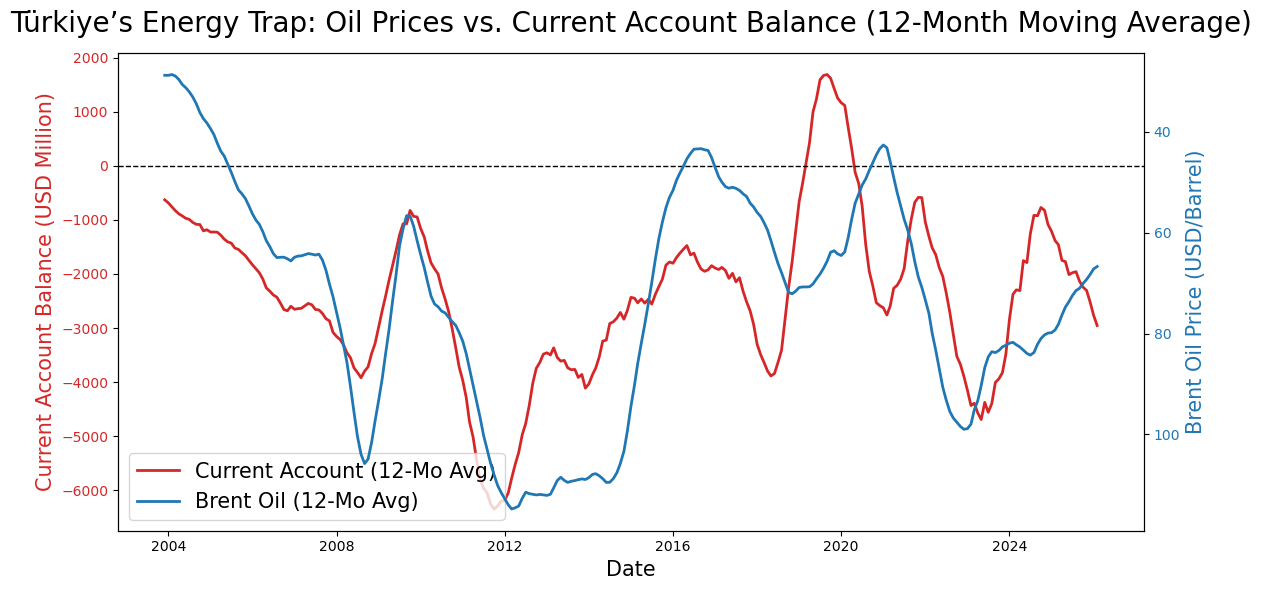

In [48]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.set_xlabel('Date', fontsize=15)

ax1.set_ylabel('Current Account Balance (USD Million)', color='tab:red', fontsize=15)
ax1.plot(combined_df['date'], combined_df['total_ca_smooth'], color='tab:red', linewidth=2, label='Current Account (12-Mo Avg)')

ax1.tick_params(axis='y', labelcolor='tab:red')
ax1.axhline(0, color='black', linestyle='--', linewidth=1) # adds "zero" line

ax2 = ax1.twinx()

ax2.set_ylabel('Brent Oil Price (USD/Barrel)', color='tab:blue', fontsize=15)
ax2.plot(combined_df['date'], combined_df['oil_smooth'], color='tab:blue', linewidth=2, label='Brent Oil (12-Mo Avg)')
ax2.tick_params(axis='y', labelcolor='tab:blue')

ax2.invert_yaxis()

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower left', frameon=True, fontsize=15)

plt.title('Türkiye’s Energy Trap: Oil Prices vs. Current Account Balance (12-Month Moving Average)', fontsize=20, pad=15)
fig.tight_layout()
plt.show()

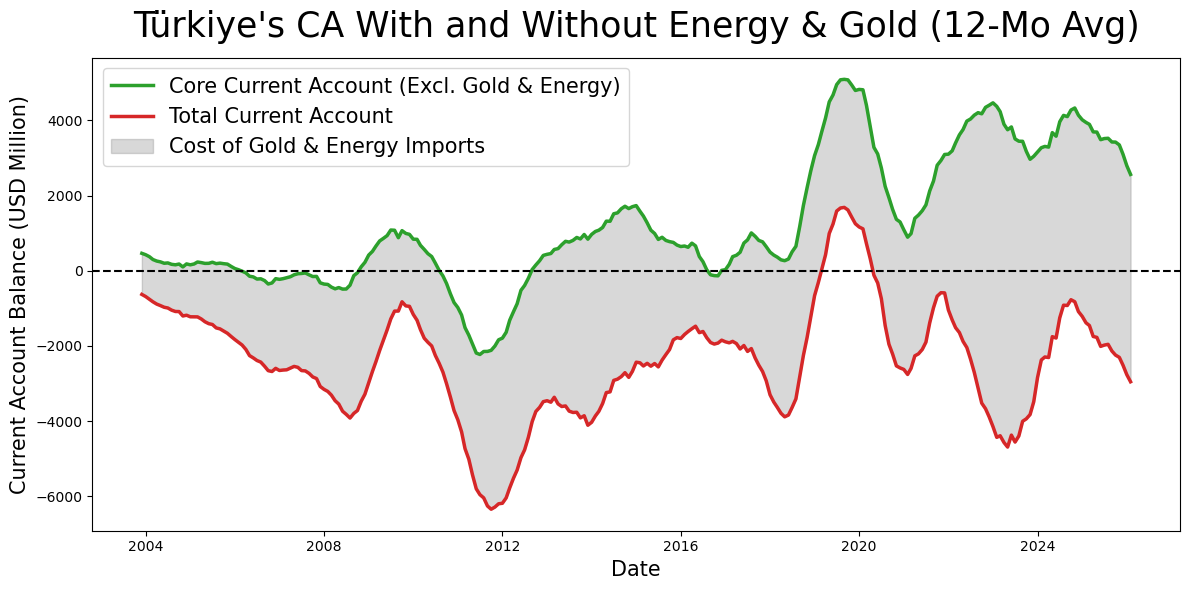

In [49]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(combined_df['date'], combined_df['core_ca_smooth'], color='tab:green', linewidth=2.5, 
        label='Core Current Account (Excl. Gold & Energy)')

ax.plot(combined_df['date'], combined_df['total_ca_smooth'], color='tab:red', linewidth=2.5, 
        label='Total Current Account')

ax.fill_between(combined_df['date'], combined_df['total_ca_smooth'], combined_df['core_ca_smooth'], 
                color='gray', alpha=0.3, label='Cost of Gold & Energy Imports')

ax.axhline(0, color='black', linestyle='--', linewidth=1.5)

ax.set_xlabel('Date', fontsize=15)
ax.set_ylabel('Current Account Balance (USD Million)', fontsize=15)
plt.title("Türkiye's CA With and Without Energy & Gold (12-Mo Avg)", fontsize=25, pad=15)

ax.legend(loc='upper left', frameon=True, fontsize=15)

fig.tight_layout()
plt.show()

### Argument 3: Geopolitical Shifts and De-dollarization
**Claim:** The persistent volatility of the Dollar-centric system is trigerring a “Stealth Erosion” of USD dominance, as nations move toward a multipolar IMS by diversifying into nontraditional currencies and bypassing global markets via bilateral swap networks.